In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
from cartopy import feature as cfeature
import netCDF4 as nc
from scipy.spatial import cKDTree
import geopandas as gpd
from cartopy.feature import ShapelyFeature


In [2]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.1_BB/atm/hist/MUSICA_production3.1_BB.cam.h4.2017-12.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-01.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-02.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-03.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-04.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-05.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-06.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-07.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-08.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-09.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-10.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-11.nc",
]

ds_list_BB = [xr.open_dataset(p) for p in file_paths_BB]
ds_all_BB = xr.concat(ds_list_BB, dim="time")


In [3]:
season_months = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}
seasons_o3 = [
    ("DJF", ['2018-12', '2018-01', '2018-02'], 0.48), 
    ("MAM", ['2018-03', '2018-04', '2018-05'], 0.48),
    ("JJA", ['2018-06', '2018-07', '2018-08'], 0.50),
    ("SON", ['2018-09', '2018-10', '2018-11'], 0.49),
]
seasons_pm25 = [
    ("DJF", ['2018-12', '2018-01', '2018-02'], 1),
    ("MAM", ['2018-03', '2018-04', '2018-05'], 1),
    ("JJA", ['2018-06', '2018-07', '2018-08'], 1),
    ("SON", ['2018-09', '2018-10', '2018-11'], 1),
]

def build_map_context():
    with nc.Dataset(scrip_filename) as f:
        lon_scrip = f.variables['grid_center_lon'][:]
        lat_scrip = f.variables['grid_center_lat'][:]
    lon_scrip_wrapped = ((lon_scrip + 180) % 360) - 180
    tree = cKDTree(np.column_stack([lon_scrip_wrapped, lat_scrip]))

    ne_shp = "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
    ne_admin1 = gpd.read_file(ne_shp)
    if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
        ne_admin1 = ne_admin1.to_crs(epsg=4326)

    ne_uk_for_mask = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
    uk_ie_union = ne_uk_for_mask.union_all()

    ne_uk_only = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR"])]
    uk_admin1_feature = ShapelyFeature(
        ne_uk_only.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='black',
        linewidth=0.35,
    )
    return tree, uk_ie_union, uk_admin1_feature


def build_bias_data(obs_csv, model_var, seasons, obs_skiprows=None):
    read_kwargs = {}
    if obs_skiprows is not None:
        read_kwargs['skiprows'] = obs_skiprows
    df = pd.read_csv(obs_csv, **read_kwargs)
    lat_all = df['Latitude'].values
    lon_all = df['Longitude'].values + 360
    lon_all_wrapped = ((lon_all + 180) % 360) - 180

    season_model = {}
    for season_name, months in season_months.items():
        sel = ds_all_BB.sel(time=ds_all_BB['time'].dt.month.isin(months))
        season_model[season_name] = (sel[model_var].mean(dim='time').isel(lev=-1) * 1e9).values

    points_sites = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lon_all_wrapped, lat_all),
        crs="EPSG:4326",
    )
    inside_sites = points_sites.geometry.within(uk_ie_union).values

    season_data = []
    for season_name, months, factor in seasons:
        selected_cols = []
        for mth in months:
            selected_cols.extend([col for col in df.columns if str(col).startswith(mth)])
        valobs = df[selected_cols].mean(axis=1).values * factor

        mask_valid = (
            np.isfinite(lon_all_wrapped)
            & np.isfinite(lat_all)
            & np.isfinite(valobs)
            & inside_sites
        )
        lonobs_wrapped = lon_all_wrapped[mask_valid]
        latobs = lat_all[mask_valid]
        valobs_valid = valobs[mask_valid]

        if lonobs_wrapped.size == 0:
            season_data.append({"name": season_name, "lon": np.array([]), "lat": np.array([]), "bias": np.array([])})
            continue

        model_field = season_model[season_name]
        _, idx_near = tree.query(np.column_stack([lonobs_wrapped, latobs]), k=1)
        model_at_sites = model_field[idx_near]

        season_data.append({
            "name": season_name,
            "lon": lonobs_wrapped,
            "lat": latobs,
            "bias": model_at_sites - valobs_valid,
        })
    return season_data


tree, uk_ie_union, uk_admin1_feature = build_map_context()

o3_data = build_bias_data(
    '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_o3/uk_o3.csv',
    'O3',
    seasons_o3,
)
pm25_data = build_bias_data(
    '/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv',
    'PM25',
    seasons_pm25,
    obs_skiprows=1,
)


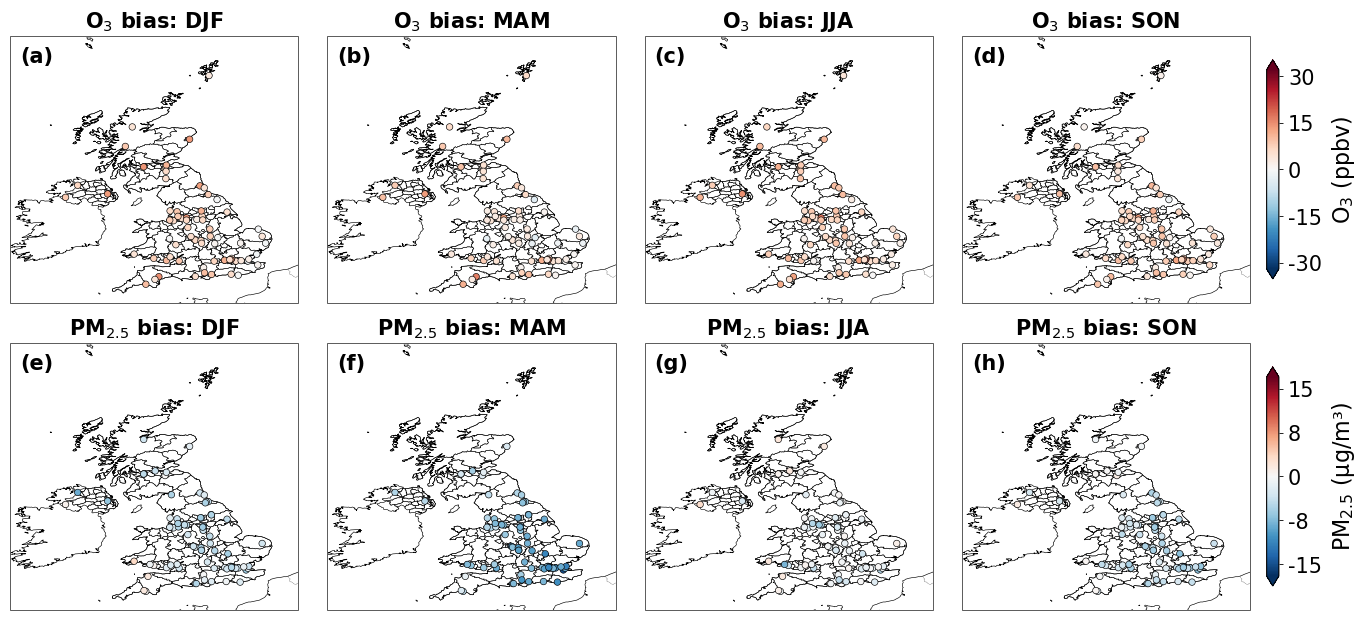

In [4]:
def lon_formatter(x, pos=None):
    return "0°" if abs(x) < 1e-9 else (f"{x:.0f}°E" if x > 0 else f"{abs(x):.0f}°W")


def lat_formatter(y, pos=None):
    return "0°" if abs(y) < 1e-9 else (f"{y:.1f}°N" if y > 0 else f"{abs(y):.1f}°S")


def style_map(ax):
    ax.set_extent([-10.5, 3, 49.5, 62], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.45)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.15)
    ax.add_feature(uk_admin1_feature)
    ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
    ax.tick_params(axis='both', which='major', labelsize=8, length=3, width=0.6)
    ax.tick_params(axis='both', which='minor', labelsize=7, length=2, width=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_edgecolor('0.35')


fig, axs = plt.subplots(
    2,
    4,
    figsize=(13.6, 6.6),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

plot_specs = [
    {
        "data": o3_data,
        "row": 0,
        "title_prefix": r"O$_3$ bias",
        "letters": ['(a)', '(b)', '(c)', '(d)'],
        "vmin": -32,
        "vmax": 32,
        "label": 'O$_3$ (ppbv)',
    },
    {
        "data": pm25_data,
        "row": 1,
        "title_prefix": r"PM$_{2.5}$ bias",
        "letters": ['(e)', '(f)', '(g)', '(h)'],
        "vmin": -17,
        "vmax": 17,
        "label": 'PM$_{2.5}$ (µg/m³)',
    },
]

cmap_bias = plt.colormaps['RdBu_r']
last_sc_by_row = [None, None]

for spec in plot_specs:
    norm_bias = plt.Normalize(vmin=spec["vmin"], vmax=spec["vmax"])
    for col, sd in enumerate(spec["data"]):
        ax = axs[spec["row"], col]
        style_map(ax)

        if sd["lon"].size > 0:
            sc = ax.scatter(
                sd["lon"],
                sd["lat"],
                c=sd["bias"],
                cmap=cmap_bias,
                norm=norm_bias,
                s=22,
                marker='o',
                edgecolors='black',
                linewidths=0.45,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )
            last_sc_by_row[spec["row"]] = sc

        ax.set_title(f'{spec["title_prefix"]}: {sd["name"]}', fontsize=15, weight='bold', pad=6)
        ax.text(
            0.035,
            0.96,
            spec["letters"][col],
            transform=ax.transAxes,
            fontsize=15,
            va='top',
            ha='left',
            weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.18', alpha=1),
        )

fig.subplots_adjust(left=0.03, right=0.95, bottom=0.07, top=0.94, wspace=0.06, hspace=0.15)

cbar_width = 0.009
cbar_pad = 0.012
cbar_height_ratio = 0.82

for row in range(2):
    if last_sc_by_row[row] is not None:
        right_ax_pos = axs[row, -1].get_position()
        cbar_height = right_ax_pos.height * cbar_height_ratio
        cbar_y0 = right_ax_pos.y0 + (right_ax_pos.height - cbar_height) / 2
        cax = fig.add_axes([
            right_ax_pos.x1 + cbar_pad,
            cbar_y0,
            cbar_width,
            cbar_height,
        ])
        cb = fig.colorbar(last_sc_by_row[row], cax=cax, orientation='vertical', extend='both')
        if row == 0:
            cb.set_ticks(np.arange(-30, 31, 15))  # O3: -30, -20, ..., 30
        else:
            cb.set_ticks(np.arange(-15, 16, 7.5))   # PM2.5: -15, -10, ..., 15
        cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}"))

        cb.set_label(plot_specs[row]["label"], fontsize=16, rotation=90, labelpad=6)
        cb.ax.tick_params(labelsize=15, length=3, width=0.6)


In [ ]:
def pad_season_site_data(season_data):
    max_sites = max((sd["lon"].size for sd in season_data), default=0)
    lon = np.full((len(season_data), max_sites), np.nan)
    lat = np.full((len(season_data), max_sites), np.nan)
    bias = np.full((len(season_data), max_sites), np.nan)

    for i, sd in enumerate(season_data):
        n_sites = sd["lon"].size
        lon[i, :n_sites] = sd["lon"]
        lat[i, :n_sites] = sd["lat"]
        bias[i, :n_sites] = sd["bias"]
    return lon, lat, bias


o3_lon, o3_lat, o3_bias = pad_season_site_data(o3_data)
pm25_lon, pm25_lat, pm25_bias = pad_season_site_data(pm25_data)
season_names = [sd["name"] for sd in o3_data]

figure_ds = xr.Dataset(
    data_vars={
        "o3_lon": (("season", "o3_site"), o3_lon),
        "o3_lat": (("season", "o3_site"), o3_lat),
        "o3_bias": (("season", "o3_site"), o3_bias),
        "pm25_lon": (("season", "pm25_site"), pm25_lon),
        "pm25_lat": (("season", "pm25_site"), pm25_lat),
        "pm25_bias": (("season", "pm25_site"), pm25_bias),
    },
    coords={
        "season": season_names,
        "o3_site": np.arange(o3_lon.shape[1]),
        "pm25_site": np.arange(pm25_lon.shape[1]),
    },
    attrs={
        "figure": "FigureS10",
        "o3_bias_units": "ppbv",
        "pm25_bias_units": "ug m-3",
        "o3_colorbar_vmin": -32,
        "o3_colorbar_vmax": 32,
        "pm25_colorbar_vmin": -17,
        "pm25_colorbar_vmax": 17,
        "map_extent": "[-10.5, 3, 49.5, 62]",
    },
)

figure_ds["o3_lon"].attrs["units"] = "degrees_east"
figure_ds["o3_lat"].attrs["units"] = "degrees_north"
figure_ds["o3_bias"].attrs["units"] = "ppbv"
figure_ds["pm25_lon"].attrs["units"] = "degrees_east"
figure_ds["pm25_lat"].attrs["units"] = "degrees_north"
figure_ds["pm25_bias"].attrs["units"] = "ug m-3"

figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
os.makedirs(figure_data_dir, exist_ok=True)
figure_ds.to_netcdf(os.path.join(figure_data_dir, "FigureS10.nc"))


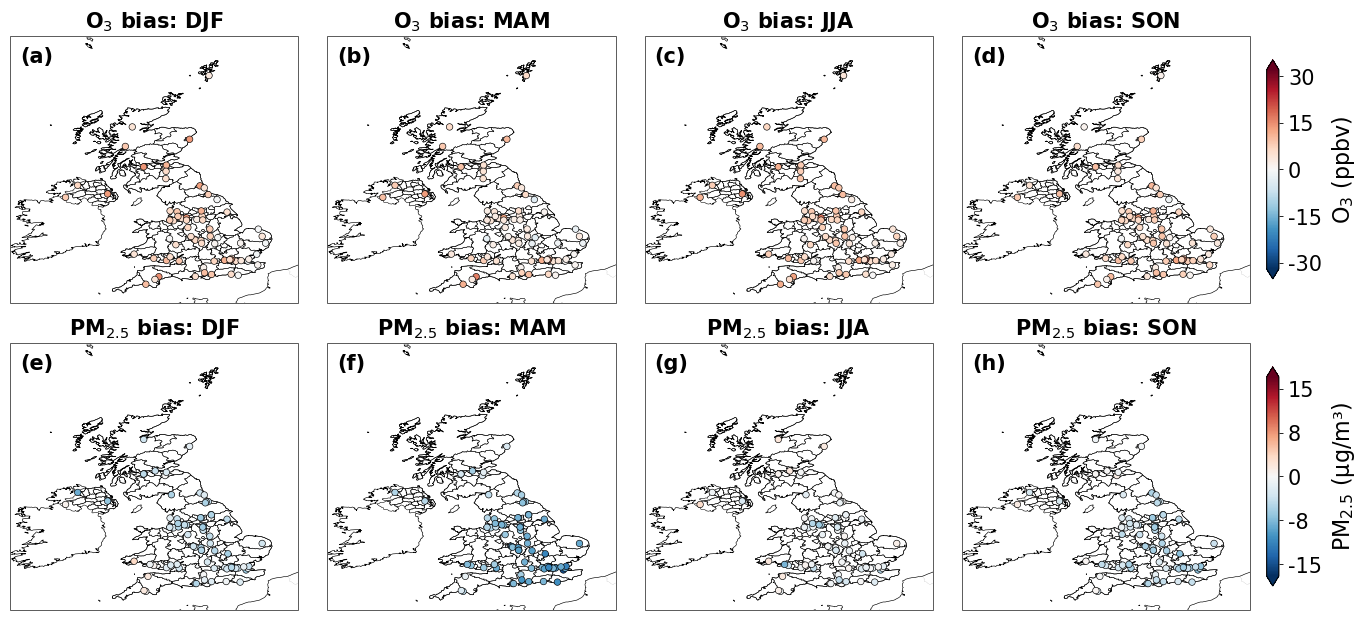

In [6]:
figure_data_path = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS10.nc"
figure_ds = xr.open_dataset(figure_data_path)

ne_shp = "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
ne_admin1 = gpd.read_file(ne_shp)
if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)
ne_uk_only = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR"])]
uk_admin1_feature = ShapelyFeature(
    ne_uk_only.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='black',
    linewidth=0.35,
)

def lon_formatter(x, pos=None):
    return "0°" if abs(x) < 1e-9 else (f"{x:.0f}°E" if x > 0 else f"{abs(x):.0f}°W")


def lat_formatter(y, pos=None):
    return "0°" if abs(y) < 1e-9 else (f"{y:.1f}°N" if y > 0 else f"{abs(y):.1f}°S")


def style_map(ax):
    ax.set_extent([-10.5, 3, 49.5, 62], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.45)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.05)
    ax.add_feature(uk_admin1_feature)
    ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
    ax.tick_params(axis='both', which='major', labelsize=8, length=3, width=0.6)
    ax.tick_params(axis='both', which='minor', labelsize=7, length=2, width=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_edgecolor('0.35')


fig, axs = plt.subplots(
    2,
    4,
    figsize=(13.6, 6.6),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

plot_specs = [
    {
        "lon": figure_ds["o3_lon"],
        "lat": figure_ds["o3_lat"],
        "bias": figure_ds["o3_bias"],
        "row": 0,
        "title_prefix": r"O$_3$ bias",
        "letters": ['(a)', '(b)', '(c)', '(d)'],
        "vmin": -32,
        "vmax": 32,
        "label": 'O$_3$ (ppbv)',
    },
    {
        "lon": figure_ds["pm25_lon"],
        "lat": figure_ds["pm25_lat"],
        "bias": figure_ds["pm25_bias"],
        "row": 1,
        "title_prefix": r"PM$_{2.5}$ bias",
        "letters": ['(e)', '(f)', '(g)', '(h)'],
        "vmin": -17,
        "vmax": 17,
        "label": 'PM$_{2.5}$ (µg/m³)',
    },
]

cmap_bias = plt.colormaps['RdBu_r']
last_sc_by_row = [None, None]
season_names = figure_ds["season"].values.astype(str)

for spec in plot_specs:
    norm_bias = plt.Normalize(vmin=spec["vmin"], vmax=spec["vmax"])
    for col, season_name in enumerate(season_names):
        ax = axs[spec["row"], col]
        style_map(ax)

        lon = spec["lon"].isel(season=col).values
        lat = spec["lat"].isel(season=col).values
        bias = spec["bias"].isel(season=col).values
        valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(bias)

        if valid.any():
            sc = ax.scatter(
                lon[valid],
                lat[valid],
                c=bias[valid],
                cmap=cmap_bias,
                norm=norm_bias,
                s=22,
                marker='o',
                edgecolors='black',
                linewidths=0.45,
                rasterized=True,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )
            last_sc_by_row[spec["row"]] = sc

        ax.set_title(f'{spec["title_prefix"]}: {season_name}', fontsize=15, weight='bold', pad=6)
        ax.text(
            0.035,
            0.96,
            spec["letters"][col],
            transform=ax.transAxes,
            fontsize=15,
            va='top',
            ha='left',
            weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.18', alpha=1),
        )

fig.subplots_adjust(left=0.03, right=0.95, bottom=0.07, top=0.94, wspace=0.06, hspace=0.15)

cbar_width = 0.009
cbar_pad = 0.012
cbar_height_ratio = 0.82

for row in range(2):
    if last_sc_by_row[row] is not None:
        right_ax_pos = axs[row, -1].get_position()
        cbar_height = right_ax_pos.height * cbar_height_ratio
        cbar_y0 = right_ax_pos.y0 + (right_ax_pos.height - cbar_height) / 2
        cax = fig.add_axes([
            right_ax_pos.x1 + cbar_pad,
            cbar_y0,
            cbar_width,
            cbar_height,
        ])
        cb = fig.colorbar(last_sc_by_row[row], cax=cax, orientation='vertical', extend='both')
        if row == 0:
            cb.set_ticks(np.arange(-30, 31, 15))
        else:
            cb.set_ticks(np.arange(-15, 16, 7.5))
        cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}"))

        cb.set_label(plot_specs[row]["label"], fontsize=16, rotation=90, labelpad=6)
        cb.ax.tick_params(labelsize=15, length=3, width=0.6)

from pathlib import Path

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS10.png"
pdf_path = FIGURES_DIR / "FigureS10.pdf"

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
